In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_excel("Dataset markets.xlsx")
df.head()

,product_id,product_name,package_size,brand,private_label,comparability_flag,comparability_note,category,chain,price_eur,unit,price_per_unit,display_unit,uses,cost_per_use,date,data_source
0,dairy_milk_whole_1L,Leche entera,1L,Hacendado,yes,comparable,NaN,dairy,Mercadona,0.96,L,0.960000,€/L,NaN,NaN,2026-04-19,website
1,dairy_milk_semi_1L,Leche semidesnatada,1L,Hacendado,yes,comparable,NaN,dairy,Mercadona,0.84,L,0.840000,€/L,NaN,NaN,2026-04-19,website
2,dairy_yogurt_greek_1kg,Yogur griego natural,1kg,Hacendado,yes,comparable,NaN,dairy,Mercadona,2.20,kg,2.200000,€/kg,NaN,NaN,2026-04-19,website
3,dairy_yogurt_natural_pack_125g,Yogur natural,6x125g,Hacendado,yes,comparable,NaN,dairy,Mercadona,1.00,kg,1.333333,€/kg,NaN,NaN,2026-04-19,website
4,dairy_yogurt_natural_pack_120g_branded,Yogur natural Danone,8x120g,Danone,no,comparable,NaN,dairy,Mercadona,1.99,kg,2.072917,€/kg,NaN,NaN,2026-04-19,website


In [36]:
print(df.shape)
print(df.columns)
df.info()

(150, 17)
Index(['product_id', 'product_name', 'package_size', 'brand', 'private_label',
       'comparability_flag', 'comparability_note', 'category', 'chain',
       'price_eur', 'unit', 'price_per_unit', 'display_unit', 'uses',
       'cost_per_use', 'date', 'data_source'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   product_id          150 non-null    str           
 1   product_name        150 non-null    str           
 2   package_size        150 non-null    str           
 3   brand               150 non-null    str           
 4   private_label       150 non-null    str           
 5   comparability_flag  150 non-null    str           
 6   comparability_note  2 non-null      str           
 7   category            150 non-null    str           
 8   chain               150 non-null    str     

In [37]:
# Average price by chain

avg_price_chain = (
    df.groupby("chain")["price_per_unit"]
    .mean()
    .round(3)
    .sort_values()
    .reset_index()
)

display(avg_price_chain)

,chain,price_per_unit
0,Mercadona,3.870
1,Consum,4.206
2,Dia,4.337
3,Carrefour,4.352
4,Alcampo,4.364


In [38]:
# Missing values
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary)

# Unique values in key columns
for col in ["chain", "category", "private_label"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

comparability_note    148
uses                  126
cost_per_use          126
product_id              0
product_name            0
private_label           0
comparability_flag      0
brand                   0
package_size            0
chain                   0
category                0
price_eur               0
unit                    0
display_unit            0
price_per_unit          0
date                    0
data_source             0
dtype: int64


chain:
chain
Consum       31
Dia          31
Mercadona    30
Carrefour    29
Alcampo      29
Name: count, dtype: int64

category:
category
dairy            35
snacks           34
breakfast        33
cleaning         24
fresh produce    24
Name: count, dtype: int64

private_label:
private_label
yes    117
no      33
Name: count, dtype: int64


In [39]:
# How many chains per product_id?
coverage = (
    df.groupby("product_id")["chain"]
    .nunique()
    .sort_values()
    .reset_index(name="n_chains")
)

display(coverage)

# Products with fewer than expected chains
display(coverage[coverage["n_chains"] < 5])

,product_id,n_chains
0,breakfast_cereals_cornflakes_500g_branded,4
1,breakfast_juice_orange_not_from_concentrate_1L,4
2,cleaning_dishwasher_tablets_approx_30u_branded,4
3,fresh_eggs_size_M_12u,4
4,snacks_crisps_salted_248g_branded,4
5,breakfast_coffee_ground_approx_250g,5
6,breakfast_coffee_capsules_with_milk_16,5
7,breakfast_cereals_cornflakes_500g,5
8,cleaning_dishwasher_gel_approx_750ml,5
9,cleaning_dishwasher_tablets_approx_30u,5


,product_id,n_chains
0,breakfast_cereals_cornflakes_500g_branded,4
1,breakfast_juice_orange_not_from_concentrate_1L,4
2,cleaning_dishwasher_tablets_approx_30u_branded,4
3,fresh_eggs_size_M_12u,4
4,snacks_crisps_salted_248g_branded,4


In [40]:
# Average price by category and by chain

avg_price_category_chain = (
    df.groupby(["category", "chain"])["price_per_unit"]
    .mean()
    .reset_index()
)

pivot_category_chain = avg_price_category_chain.pivot(
    index="category",
    columns="chain",
    values="price_per_unit"
)

display(pivot_category_chain.round(3))

chain,Alcampo,Carrefour,Consum,Dia,Mercadona
category,,,,,
breakfast,4.105,4.022,4.536,4.257,4.202
cleaning,1.594,1.507,1.304,1.670,1.275
dairy,3.515,3.291,3.394,3.274,3.213
fresh produce,2.047,2.142,1.858,1.882,1.804
snacks,8.672,8.991,8.440,9.137,8.132


In [42]:
# Cheapest chain by category

cheapest_by_category = (
    avg_price_category_chain.loc[
        avg_price_category_chain.groupby("category")["price_per_unit"].idxmin()
    ]
    .sort_values("category")
    .round(3)
)

display(cheapest_by_category)

,category,chain,price_per_unit
1,breakfast,Carrefour,4.022
9,cleaning,Mercadona,1.275
14,dairy,Mercadona,3.213
19,fresh produce,Mercadona,1.804
24,snacks,Mercadona,8.132


In [47]:
pl_vs_brand = (
    df.groupby("private_label")["price_per_unit"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .round(3)
)

display(pl_vs_brand.round(4))

pl_vs_brand_cat = (
    df.groupby(["category", "private_label"])["price_per_unit"]
    .mean()
    .reset_index()
    .round(3)
)

display(pl_vs_brand_cat.round(4))

,private_label,count,mean,median
0,no,33,3.771,2.073
1,yes,117,4.353,2.290


,category,private_label,price_per_unit
0,breakfast,no,4.772
1,breakfast,yes,4.000
2,cleaning,no,0.346
3,cleaning,yes,1.689
4,dairy,no,3.040
5,dairy,yes,3.399
6,fresh produce,no,1.052
7,fresh produce,yes,2.382
8,snacks,no,9.733
9,snacks,yes,8.510


Basic visualizations

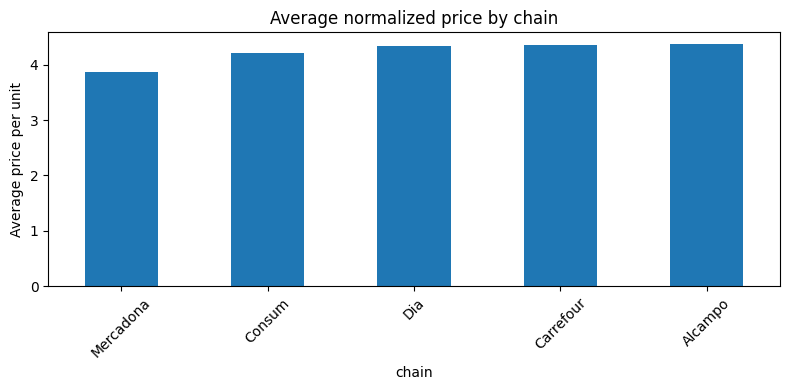

In [48]:
# Bar chart: average price by chain

avg_price_chain.plot(
    kind="bar",
    x="chain",
    y="price_per_unit",
    legend=False,
    figsize=(8, 4)
)

plt.ylabel("Average price per unit")
plt.title("Average normalized price by chain")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

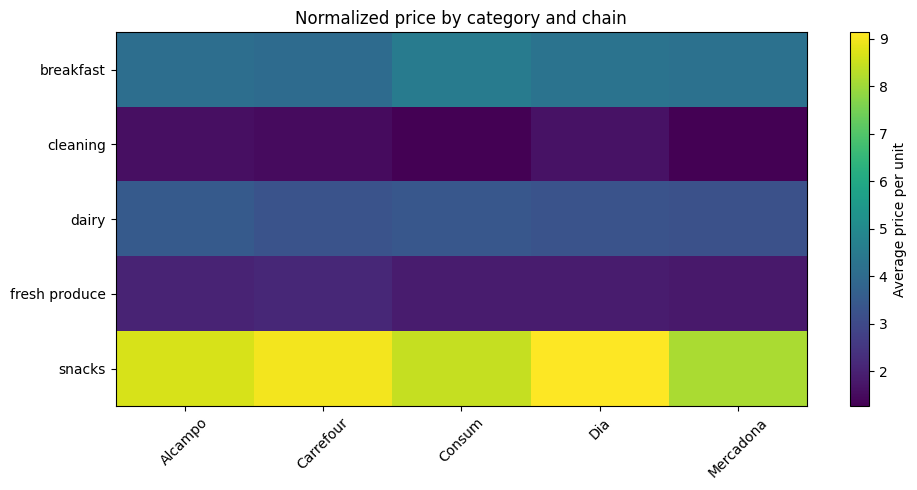

In [49]:
# Heatmap simple

plt.figure(figsize=(10, 5))
plt.imshow(pivot_category_chain, aspect="auto")
plt.colorbar(label="Average price per unit")
plt.xticks(range(len(pivot_category_chain.columns)), pivot_category_chain.columns, rotation=45)
plt.yticks(range(len(pivot_category_chain.index)), pivot_category_chain.index)
plt.title("Normalized price by category and chain")
plt.tight_layout()
plt.show()

“While the heatmap suggests differences across categories, direct comparisons between categories are not meaningful due to differences in unit normalization (€/kg, €/L, €/unit). Therefore, analysis focuses on within-category comparisons.”

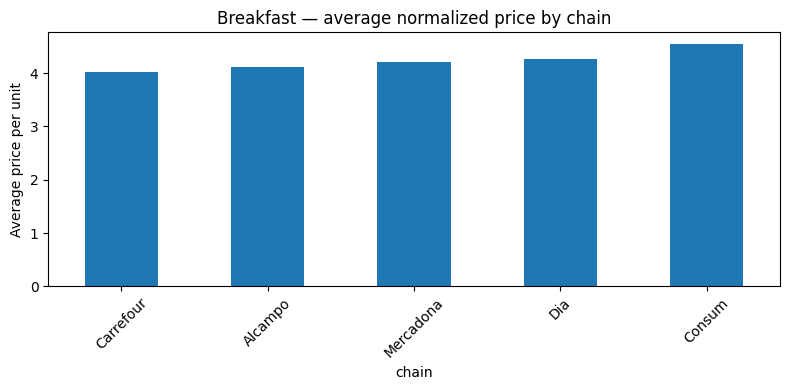

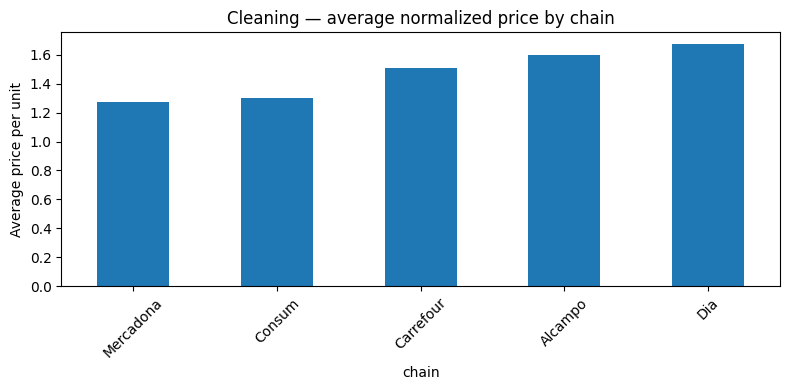

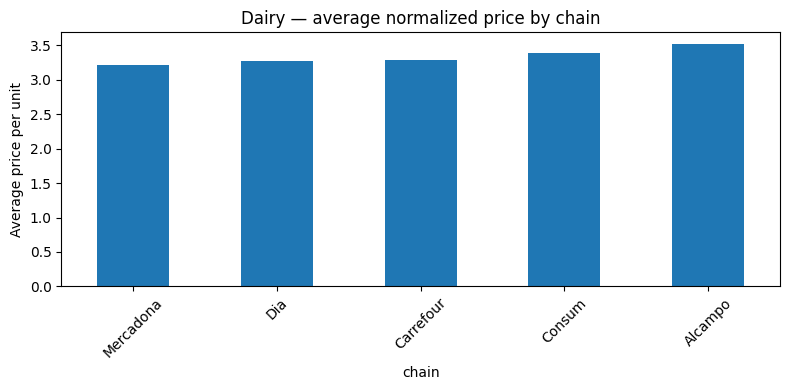

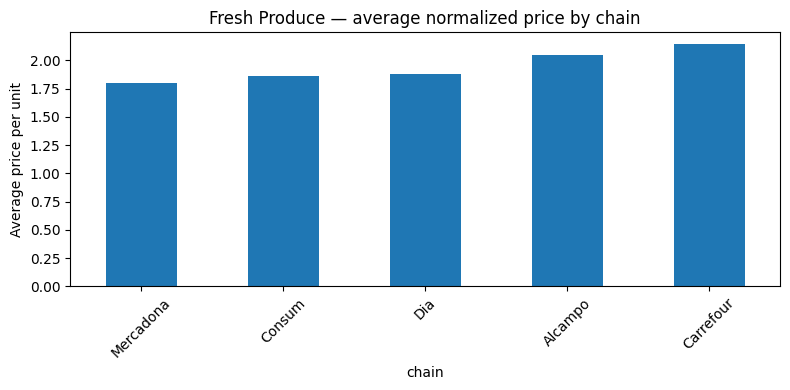

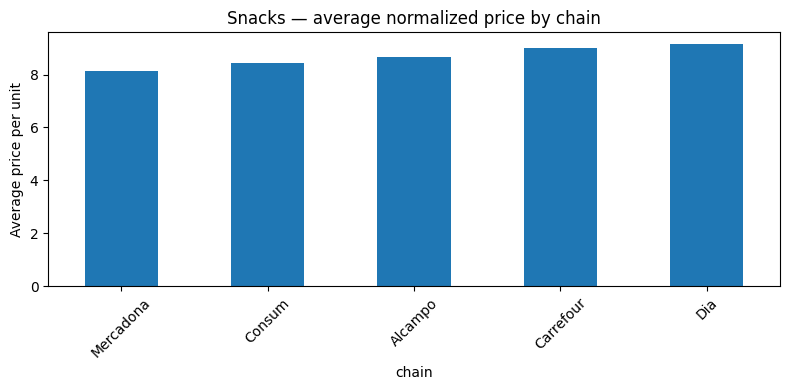

In [64]:
categories = sorted(df["category"].dropna().unique())

for category in categories:
    subset = df[df["category"] == category]

    avg_prices = (
        subset.groupby("chain")["price_per_unit"]
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(8, 4))
    avg_prices.plot(kind="bar")
    plt.ylabel("Average price per unit")
    plt.title(f"{category.title()} — average normalized price by chain")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**OUTLIERS**

In [54]:
# Top expensive normalized products

expensive = df.sort_values("price_per_unit", ascending=False)
display(expensive[["product_id", "chain", "brand", "package_size", "price_eur", "price_per_unit"]].head(15).round(3))

,product_id,chain,brand,package_size,price_eur,price_per_unit
89,snacks_chocolate_dark_85_100g,Carrefour,Carrefour Selection,100g,1.95,19.500
120,snacks_chocolate_dark_85_100g,Dia,Dia Temptation,100g,1.95,19.500
60,snacks_chocolate_dark_85_100g,Consum,Consum,100g,1.75,17.500
29,snacks_chocolate_dark_85_100g,Mercadona,Hacendado,100g,1.75,17.500
149,snacks_chocolate_dark_85_100g,Alcampo,Auchan,100g,1.74,17.400
115,snacks_crisps_salted_248g_branded,Dia,Lay's,248g,2.89,11.653
84,snacks_crisps_salted_248g_branded,Carrefour,Lay's,248g,2.89,11.653
147,snacks_biscuits_cookies_approx_200g,Alcampo,Auchan,184g,1.99,10.815
144,snacks_crisps_salted_248g_branded,Alcampo,Lay's,248g,2.65,10.685
12,breakfast_coffee_ground_approx_250g,Mercadona,Hacendado,250g,2.60,10.400


In [55]:
# Lowest normalized products

cheap = df.sort_values("price_per_unit", ascending=True)
display(cheap[["product_id", "chain", "brand", "package_size", "price_eur", "price_per_unit"]].head(15).round(3))

,product_id,chain,brand,package_size,price_eur,price_per_unit
104,cleaning_dishwasher_tablets_approx_30u,Dia,Dia Super Paco,40u,3.45,0.086
14,cleaning_dishwasher_tablets_approx_30u,Mercadona,Bosque Verde,30u,2.95,0.098
44,cleaning_dishwasher_tablets_approx_30u,Consum,Consum,30u,2.95,0.098
134,cleaning_dishwasher_tablets_approx_30u,Alcampo,Auchan,45u,4.75,0.106
74,cleaning_dishwasher_tablets_approx_30u,Carrefour,Carrefour Expert,40u,4.35,0.109
48,cleaning_laundry_capsules_approx_25u,Consum,Consum,24u,3.99,0.166
15,cleaning_dishwasher_tablets_approx_30u_branded,Mercadona,Fairy,35u,5.85,0.167
18,cleaning_laundry_capsules_approx_25u,Mercadona,Bosque Verde,24u,4.40,0.183
137,cleaning_laundry_capsules_approx_25u,Alcampo,Auchan,30u,5.50,0.183
108,cleaning_laundry_capsules_approx_25u,Dia,Dia Super Paco,20u,3.69,0.184


Costs per use

In [58]:
cleaning_use = df[df["cost_per_use"].notna()].copy()

display(
    cleaning_use[
        ["product_id", "chain", "brand", "price_eur", "price_per_unit", "uses", "cost_per_use"]
    ].sort_values(["product_id", "chain"]).round(3)
)

,product_id,chain,brand,price_eur,price_per_unit,uses,cost_per_use
135,cleaning_dishwasher_gel_approx_750ml,Alcampo,Auchan,3.42,4.750,36.0,0.095
76,cleaning_dishwasher_gel_approx_750ml,Carrefour,Carrefour Expert,4.25,4.722,45.0,0.094
46,cleaning_dishwasher_gel_approx_750ml,Consum,Consum,3.35,4.653,36.0,0.093
106,cleaning_dishwasher_gel_approx_750ml,Dia,Dia Super Paco,4.09,6.312,36.0,0.114
16,cleaning_dishwasher_gel_approx_750ml,Mercadona,Bosque Verde,3.45,4.792,36.0,0.096
134,cleaning_dishwasher_tablets_approx_30u,Alcampo,Auchan,4.75,0.106,45.0,0.106
74,cleaning_dishwasher_tablets_approx_30u,Carrefour,Carrefour Expert,4.35,0.109,40.0,0.109
44,cleaning_dishwasher_tablets_approx_30u,Consum,Consum,2.95,0.098,30.0,0.098
104,cleaning_dishwasher_tablets_approx_30u,Dia,Dia Super Paco,3.45,0.086,40.0,0.086
14,cleaning_dishwasher_tablets_approx_30u,Mercadona,Bosque Verde,2.95,0.098,30.0,0.098


In [60]:

cost_use_summary = (
    df[df["cost_per_use"].notna()]
    .groupby(["product_id", "chain"])["cost_per_use"]
    .mean()
    .reset_index()
    .round(3)
)
display(cost_use_summary.sort_values(["product_id", "cost_per_use"]))

,product_id,chain,cost_per_use
2,cleaning_dishwasher_gel_approx_750ml,Consum,0.093
1,cleaning_dishwasher_gel_approx_750ml,Carrefour,0.094
0,cleaning_dishwasher_gel_approx_750ml,Alcampo,0.095
4,cleaning_dishwasher_gel_approx_750ml,Mercadona,0.096
3,cleaning_dishwasher_gel_approx_750ml,Dia,0.114
8,cleaning_dishwasher_tablets_approx_30u,Dia,0.086
7,cleaning_dishwasher_tablets_approx_30u,Consum,0.098
9,cleaning_dishwasher_tablets_approx_30u,Mercadona,0.098
5,cleaning_dishwasher_tablets_approx_30u,Alcampo,0.106
6,cleaning_dishwasher_tablets_approx_30u,Carrefour,0.109
